In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


file_path =  "../../data/raw/WESAD/S2/S2_respiban.txt"

data = pd.read_csv(
    file_path,
    sep="\t",
    comment="#",        # ignores JSON header + metadata
    header=None,
    engine="python"
)

 

(4442067, 11)
   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN
3   3   0  30374  14701  32569  29553  37405  32341  31671  31076 NaN
4   4   0  30103  14684  32794  29561  37409  32342  31681  31365 NaN


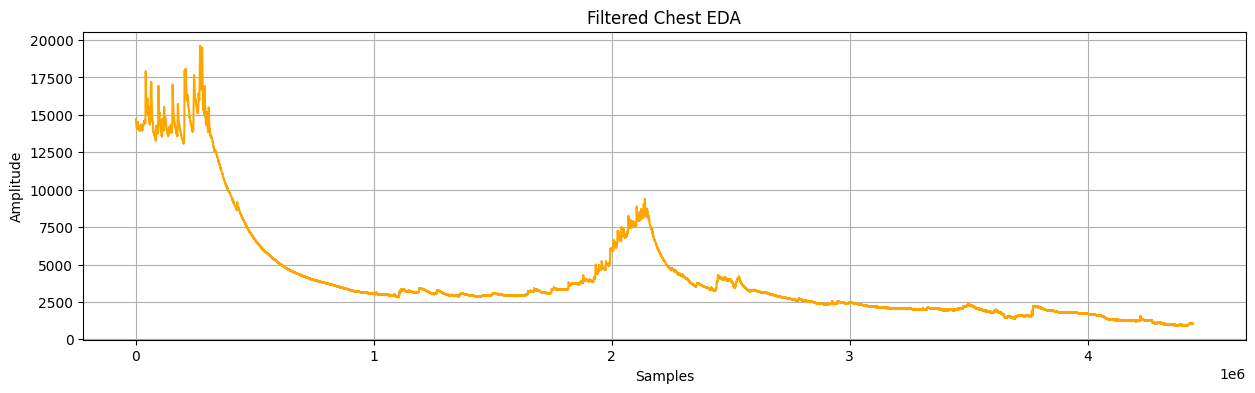

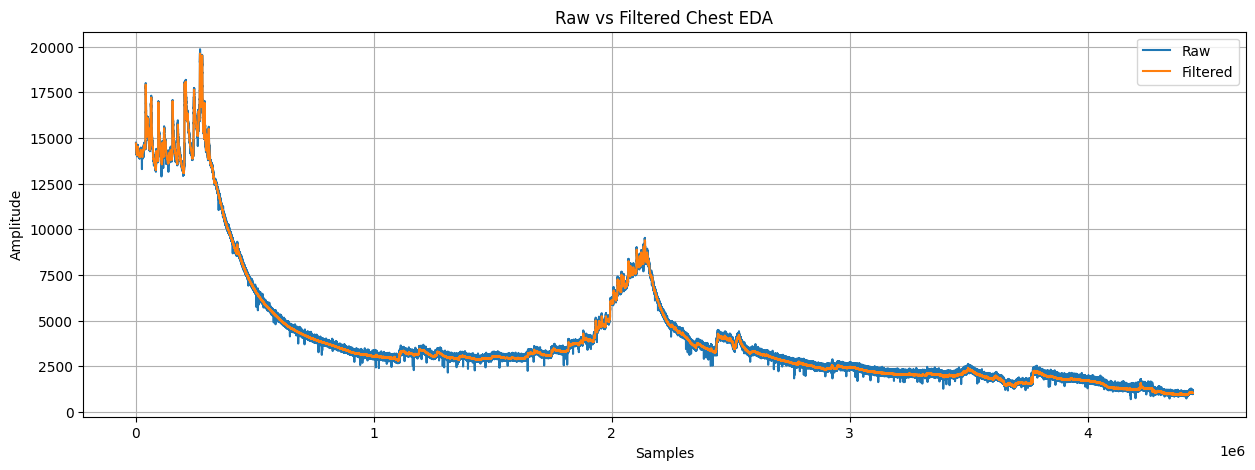

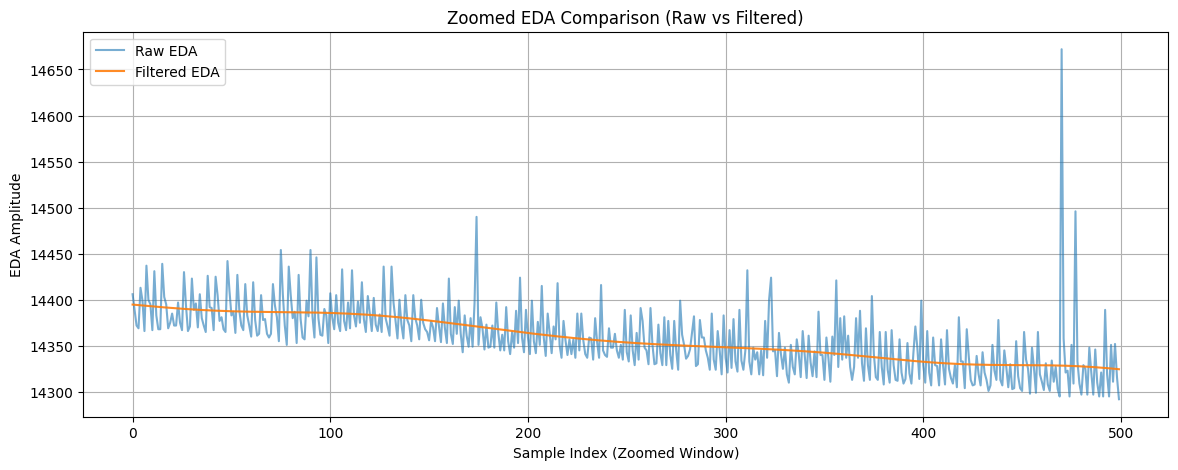

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks

EDA = data.iloc[:,3].values     #load eda

EDA = data.iloc[:,3].values         #remove dc offset

fs = 700
cutoff = 5
order = 4

nyquist = fs / 2

b, a = butter(
    order,
    cutoff / nyquist,
    btype="low"
)

EDA_filtered = filtfilt(b, a, EDA)

plt.figure(figsize=(15,4))

plt.plot(EDA_filtered,color="orange")

plt.title("Filtered Chest EDA")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

# raw vs filtered
plt.figure(figsize=(15,5))

plt.plot(EDA,
         label="Raw")

plt.plot(EDA_filtered,
         label="Filtered")

plt.title("Raw vs Filtered Chest EDA")

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.legend()
plt.grid(True)

plt.show()
 

EDA = np.array(EDA)
EDA_filtered = np.array(EDA_filtered)
start = 1000        # change this
end = 1500          # small segment for zoom

# -----------------------------
# Slice signals
# -----------------------------
raw_zoom = EDA[start:end]
filtered_zoom = EDA_filtered[start:end]

# -----------------------------
# Plot zoomed comparison
# -----------------------------
plt.figure(figsize=(14, 5))

plt.plot(raw_zoom, label="Raw EDA", alpha=0.6)
plt.plot(filtered_zoom, label="Filtered EDA", alpha=0.9)

plt.title("Zoomed EDA Comparison (Raw vs Filtered)")
plt.xlabel("Sample Index (Zoomed Window)")
plt.ylabel("EDA Amplitude")
plt.legend()
plt.grid()

plt.show()


In [41]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# -----------------------------
# METRIC FUNCTIONS
# -----------------------------
def noise_estimate(signal):
    return np.std(np.diff(signal))

def baseline_drift(signal):
    return np.mean(signal) - np.median(signal)

def outlier_count(signal):
    mean = np.mean(signal)
    std = np.std(signal)
    if std == 0:
        return 0
    z = (signal - mean) / std
    return np.sum(np.abs(z) > 3)

def scr_peaks(signal, fs=4):
    peaks, _ = find_peaks(signal, prominence=0.01, distance=int(fs*1))
    return len(peaks)

def slope_variability(signal):
    return np.std(np.diff(signal))

# -----------------------------
# FULL METRIC REPORT FUNCTION
# -----------------------------
def compute_metrics(signal, fs=4):
    return {
        "Mean": np.mean(signal),
        "Std": np.std(signal),
        "Noise Estimate": noise_estimate(signal),
        "Baseline Drift": baseline_drift(signal),
        "Outliers (>3σ)": outlier_count(signal),
        "SCR Peaks": scr_peaks(signal, fs),
        "Slope Variability": slope_variability(signal)
    }

# -----------------------------
# LOAD YOUR SIGNALS
# -----------------------------
# Replace with your actual arrays
# eda_raw = ...
# eda_filtered = ...

raw_metrics = compute_metrics(EDA)
filtered_metrics = compute_metrics(EDA_filtered)

# -----------------------------
# CREATE COMPARISON TABLE
# -----------------------------
rows = []

for key in raw_metrics.keys():
    raw_val = raw_metrics[key]
    filt_val = filtered_metrics[key]

    # % change
    if raw_val != 0:
        pct_change = ((filt_val - raw_val) / raw_val) * 100
    else:
        pct_change = np.nan

    rows.append([key, raw_val, filt_val, pct_change])

df = pd.DataFrame(rows, columns=[
    "Metric",
    "Raw EDA",
    "Filtered EDA",
    "% Change"
])

# -----------------------------
# DISPLAY TABLE
# -----------------------------
pd.set_option("display.float_format", "{:.4f}".format)
print(df)

 

              Metric     Raw EDA  Filtered EDA  % Change
0               Mean   4160.4218     4160.4218   -0.0000
1                Std   3548.2578     3547.9308   -0.0092
2     Noise Estimate     67.9711        0.2317  -99.6592
3     Baseline Drift   1111.4218     1116.2164    0.4314
4     Outliers (>3σ) 120285.0000   120323.0000    0.0316
5          SCR Peaks 778297.0000    22037.0000  -97.1686
6  Slope Variability     67.9711        0.2317  -99.6592


| Metric            | Result Summary   | % Change    | Interpretation                         |
| ----------------- | ---------------- | ----------- | -------------------------------------- |
| Mean              | Stable (~4160)   | ~0%         | Signal baseline unchanged              |
| Std Deviation     | Slightly reduced | -0.01%      | Minor smoothing effect                 |
| Noise Estimate    | Strong reduction | **-99.66%** | 🔥 Excellent noise removal             |
| Baseline Drift    | Slight increase  | +0.43%      | Negligible drift change                |
| Outliers (>3σ)    | Slight increase  | +0.03%      | Essentially unchanged                  |
| SCR Peaks         | Major reduction  | **-97.17%** | Strong filtering of activity/artifacts |
| Slope Variability | Strong reduction | **-99.66%** | Very smooth filtered signal            |


The filtering process significantly improves EDA signal quality, achieving ~99.66% noise and variability reduction, while maintaining baseline stability. However, a large reduction in SCR peaks (-97.17%) suggests that the filter may be overly aggressive and could be suppressing physiological responses.